# Banzhaf Index Example

In this example we demonstrate the implementation of Banzhaf values. The considered example is similar to that introduced in $\Upsilon$-values notebook. We restate it here: There are three binary features $x_1,x_2$ and $x_3$; the binary classifier $\kappa$ has the following classification:

 | $x_1$ | $x_2$ | $x_3$ | $\kappa$ (classifier) |
 | :-: | :-: | :-: | :-: |
 | 0 | 0 | 0 | 0 |
 | 0 | 0 | 1 | 1 |
 | 0 | 1 | 0 | 1 |
 | 0 | 1 | 1 | 0 |
 | 1 | 0 | 0 | 0 |
 | 1 | 0 | 1 | 0 |
 | 1 | 1 | 0 | 0 |
 | 1 | 1 | 1 | 0 |

As in the case of $\Upsilon$-values Example, we investigate the instance of $\langle \langle 0,0,0 \rangle, \kappa=0\rangle$.  

In [1]:
def classifier( data_pt: list[int] )-> int:
  """ Returns the value of classifier corresponding to the example 
      in explanantion is not a game
      
      Args:
      data_pt (list[int]): A binary list of length 3.
      
      Returns:
      int: The value of classifier.
  """

  if ( data_pt == [0, 0, 1] or
       data_pt == [0, 1, 0]
       ) :       return 1

  else :    return 0

Banzhaf values measures the *swininging power* of a feature with respect to a binary initial function. For example, in the voting game `similarity_set_voting_game` given below, the Banzhaf value $B_2$ for the feature $x_2$ is:

In [ ]:
import math
from itertools import product
from powerxai.banzhaf_value import banzhaf_value

def similarity_set( features: list[int], fixed_data_pt: list[int] )-> list[int]:
  """ Returns the set of data points which agree on the features of
  the fixed_data_pt
  
  Args:
    features (list[int]): A listr of features.
    fixed_data_pt (list[int]): The reference data point.
  
  Returns:
    list[int]: The list of data points acquired. 
  """
  

  if features :
    prod = product( [0, 1], repeat=3 )
    data_pts = []

    for x in prod:
      k = 1

      for y in features:
        if( x[ y ] != fixed_data_pt[ y ] ): k = 0

      if( k == 1 ) :     data_pts.append ( x )

    return data_pts

  else:
    return []
  
def similarity_set_voting_game( players: list[int],
                          input: list[int], 
                          fixed_data_pt = [0,0,0] )-> float:
  """Initial Strength function as defined in the example of Explanation is not a game
  
  Args: 
    players (list[int]): List of players to be passed on.
    input (list[int]): The coalition of features we ask the initial value for.
    fixed_data_pt (list[int]): The point w.r.t. which we find the initial strength.
    
  Returns:
    float: The value w.r.t. to input.
  """

  sim = similarity_set( input, fixed_data_pt )
  sim_list = [list(x) for x in sim]

  sum = 0

  for x in sim_list:  sum = sum + classifier (x)

  final_sum = sum / math.pow( 2, 3 - (len (input)) )

  if( final_sum >= 0.3 ):   return 1
  else:                     return 0

print(f'The Banzhaf-value (contribution) of the 1st feature: {banzhaf_value( 2, [0,1,2], similarity_set_voting_game )}')

The Banzhaf-value (contribution) of adding the 3rd feature: -1.0


For the instance we mentioned, the $\Upsilon$-value corresponding to adding $1,2$ and $3$ features are given below. Additionally, we contrast their relative strength in the form of a graph. 

The banzhaf-value of the 1st feature: 3.0
The banzhaf-value of the 2nd feature: -1.0
The banzhaf-value of the 3rd feature: -1.0


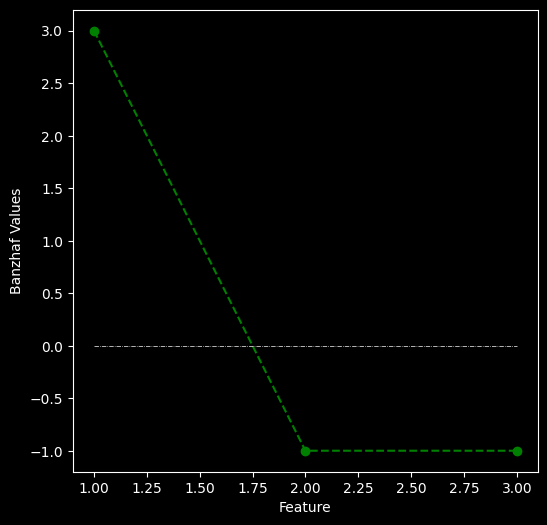

In [ ]:
from powerxai.banzhaf_value import banzhaf_value
import matplotlib.pyplot as plt
def banzhaf_value_check_similarity_set_voting_game():

  x_1 = banzhaf_value( 0, [0,1,2], similarity_set_voting_game )
  x_2 = banzhaf_value( 1, [0,1,2], similarity_set_voting_game )
  x_3 = banzhaf_value( 2, [0,1,2], similarity_set_voting_game )

  print(f'The banzhaf-value of the 1st feature: {x_1}')
  print(f'The banzhaf-value of the 2nd feature: {x_2}')
  print(f'The banzhaf-value of the 3rd feature: {x_3}')

  xaxis = [1, 2, 3]
  yaxis = [x_1, x_2, x_3]

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (6)
  fig.set_figheight (6)

  plt.xlabel( "Feature" )
  plt.ylabel( "Banzhaf Values" )
  plt.plot( xaxis, yaxis, 'go', linestyle = 'dashed' )
  plt.plot( xaxis, [0,0,0], 'w-.', linewidth = 0.5 )
  plt.show()

banzhaf_value_check_similarity_set_voting_game ()

Hence, the 1st feature has significantly more swinging power than the 2nd and 3rd. Furthermore, 2nd and 3rd feature might lead to loss i.e. decrease in the initial strength.  

## Changing the Initial value function

The calculation of Banzhaf index depends on the initial value function. In the above case, we used the `similarity_set_voting_game` inspired from [Explainability is NOT a Game](https://arxiv.org/abs/2307.07514) paper.
To demonstrate the dependence of Banzhaf-values on the initial value function, we consider two additional cases:

### Similarity Set Inverse Voting Game

Again, we investigate the instance of $\langle \langle0,0,0\rangle, \kappa=0  \rangle$, for the updated `similarity_set_inverse_voting_game` initial function.
Banzhaf-values for this function are given below, followed by a graph that constrasts them.

The banzhaf-value of the 1st feature: -2.0
The banzhaf-value of the 2nd feature: 2.0
The banzhaf-value of the 3rd feature: 2.0


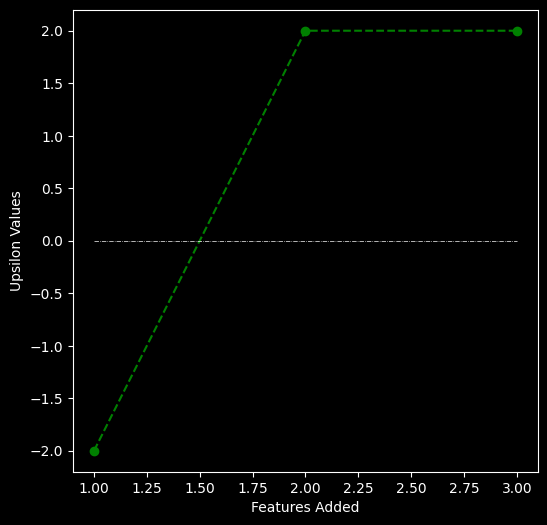

In [54]:
from powerxai.banzhaf_value import banzhaf_value
import matplotlib.pyplot as plt

import math
def similarity_set_inverse_voting_game( players: list[int] ,
                                  input: list[int],
                                  fixed_data_pt = [0,0,0] )-> float:
  """Initial Strength function counting the number 0s provided by the classifier,
  The normalisation factor is the same as in the previous case.
  
  Args: 
    players (list[int]): List of players to be passed on.
    input (list[int]): The coalition of features we ask the initial value for.
    fixed_data_pt (list[int]): The point w.r.t. which we find the initial strength.
    
  Returns:
    float: The value w.r.t. to input.
  """

  sim = similarity_set( input, fixed_data_pt )
  sim_list = [list(x) for x in sim]

  sum = 0

  for x in sim_list:    sum = sum + (1 - classifier( x ))

  final_sum = sum / math.pow( 2, 4 - (len (input)) )
  if( final_sum >= 0.3):    return 1
  else:                     return 0

def banzhaf_value_check_similarity_set_inverse_voting_game( ):

  x_1 = banzhaf_value( 0, [0,1,2], similarity_set_inverse_voting_game )
  x_2 = banzhaf_value( 1, [0,1,2], similarity_set_inverse_voting_game )
  x_3 = banzhaf_value( 2, [0,1,2], similarity_set_inverse_voting_game )

  print(f'The banzhaf-value of the 1st feature: {x_1}')
  print(f'The banzhaf-value of the 2nd feature: {x_2}')
  print(f'The banzhaf-value of the 3rd feature: {x_3}')

  xaxis = [1, 2, 3]
  yaxis = [x_1, x_2, x_3]

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (6)
  fig.set_figheight (6)

  plt.xlabel("Features Added")
  plt.ylabel("Upsilon Values")

  plt.plot(xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot(xaxis, [0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

banzhaf_value_check_similarity_set_inverse_voting_game( )

In contrast to the previous case, features 2 and 3 significantly more swinging power than the 1st feature. In this case, feature 1 looses swinging power. However, feature 2 and 3 have the same value, as seen in the previous case.

### Sufficiency Voting Game

Finally, the instance of $\langle \langle0,0,0\rangle, \kappa=0  \rangle$ is investigated against the `aggregation_sufficiency` function.
Banzhaf-values for this function are given below, followed by a graph that constrasts them.

The banzhaf_value of 1: 1.5
The banzhaf_value of 2: 2.5
The banzhaf_value of 3: 1.5


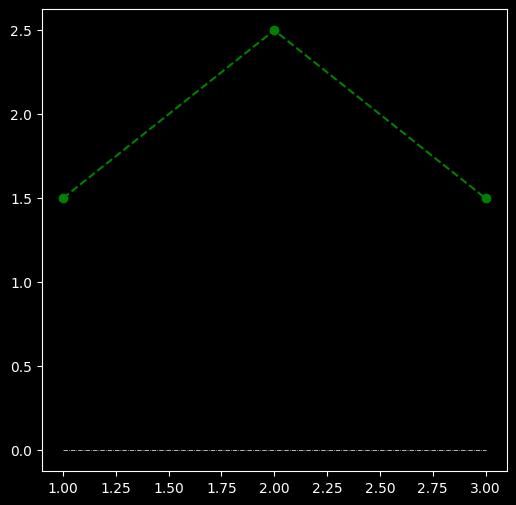

In [55]:
from itertools import product
from powerxai.coalitions import coalitions
from powerxai.upsilon_value import upsilon_value
import matplotlib.pyplot as plt

def partition_of_features(feature_set: list[int],
                           reference =0 )-> list[int]:
  """Returns the set of all data points which agree on the feature_set. 
  
  Args: 
    feature_set (list[int]): List of features considered.
    reference (list[int]): A reference data point.
    
  Returns:
    list[int]: A list of data points. 
  """


  full = list( product( (0,1), repeat=3 ) )
  list_for_feature_set =[]
  used = []
  groups = []


  for x in full:
    a = [x[i-1] for i in feature_set]
    list_for_feature_set.append( a )

  list_of_8 = [x for x in range (0,8)]

  while (set(used) != set(list_of_8)):
    list_without_used = [x for x in list_of_8 if x not in used]
    ind = []
    b = list_for_feature_set[list_without_used[0]]

    for i in list_without_used:
      if(list_for_feature_set[i] == b):
        used.append( i )
        ind.append( i )

    groups.append( ind )

  if (reference == 0): return groups
  
  else:
    k = full.index (reference)
    for x in groups:
      if (k in x): return x

def sufficiency_check_with_reference( feature_set: list[int],
                                      reference: list[int] )-> bool:
  """Checks whether a feature_set is sifficient w.r.t. a reference.
  
  Args: 
    feature_set (list[int]): The considered feature_set.
    reference (list[int]): The data point we check against.
    
  Returns:
    bool: The truth value of the sufficiency check.
  """

  group = partition_of_features( feature_set, reference )
  full = list (product ( (0,1), repeat=3 ))
  classification_1 = classifier ( list(reference) )

  for i in group:
    classification_2 = classifier( list( full[i] ) )
    if(classification_1 != classification_2): return False

  return True

def sufficiency_check( feature_set: list[int] )-> bool:
  """
    Checks whether a feature set is sufficient. 

    Args:
      feature_set (list[int]): List of features.

    Return:
      bool: Truth value of the sufficiency check.
  """

  groups = partition_of_features( feature_set )
  full = list( product( (0,1), repeat=3 ))

  for i in groups:

    classification_1 = classifier( list( full[ i[0] ]) )

    for j in i:
      classification_2 = classifier( list( full[j] ) )
      if(classification_1 != classification_2): return False

  return True

def sufficency_voting_game_with_reference( feature_set: list[int],
                                          reference: list[int] )-> float:
  """
    Initial value function defined w.r.t. sufficiency aggregartion. 

    Args:
      feature_set (list[int]): List of features.
      reference (list[int]): The reference data point.

    Return:
      float: Truth value of the sufficiency check.
  """

  possible_sub_feature_sets= coalitions( feature_set )
  sum =0

  for x in possible_sub_feature_sets:
    if (sufficiency_check_with_reference( x, reference )):      sum = sum + 1

  return sum

def sufficiency_voting_game( players: list[int],
                       feature_set: list[int] )-> float:
  """Initial value function defined w.r.t. sufficiency aggregartion.
  
    Args:
      players (list[int]): list of players to be passed on.
      feature_set (list[int]): The input of the initial function.

    Returns:
      float: The corresponding initial value.
  """

  full = list( product( (0,1), repeat=3 ) )
  sum = 0

  for x in full:
    sum = sum + sufficency_voting_game_with_reference( feature_set, x )

  return sum / 16

def banzhaf_value_check_sufficiency_voting_game( ):
  
  x_1 = banzhaf_value( 0, [0,1,2], sufficiency_voting_game )
  x_2 = banzhaf_value( 1, [0,1,2], sufficiency_voting_game )
  x_3 = banzhaf_value( 2, [0,1,2], sufficiency_voting_game )

  print(f'The banzhaf_value of 1: {x_1}')
  print(f'The banzhaf_value of 2: {x_2}')
  print(f'The banzhaf_value of 3: {x_3}')

  xaxis = [1, 2, 3]
  yaxis = [x_1, x_2, x_3]

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (6)
  fig.set_figheight (6)

  plt.plot(xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot(xaxis, [0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

banzhaf_value_check_sufficiency_voting_game( )


In this case, all of the feature have positive swinging power. Feature 2 has more swinging power than features 1 and 3, which have the same swinging power.

## Comparsion between Shapley and Banzhaf-values

Keeping the instance  $\langle \langle 0,0,0\rangle ,\kappa=0\rangle$ fixed, in this section, we compare the Shapley and Banzhaf values w.r.t. the above defined initial functions. There are three cases:

1. Similarity set based Voting Game.

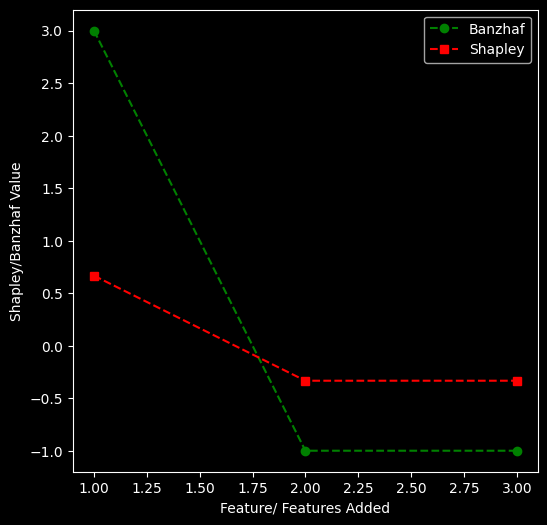

In [58]:
from powerxai.shapley_value import shapley_value

def comparison_between_values_similarity_set_voting_game():

  xaxis =[]

  yaxis_banzhaf =[]
  yaxis_shapley =[]

  for i in range (1, 4):
    xaxis. append( i )

  for i in range (0, 3):
    yaxis_banzhaf. append( banzhaf_value(i, [0,1,2], similarity_set_voting_game) )

  for i in range (0, 3):
    yaxis_shapley. append( shapley_value(i, [0,1,2], similarity_set_voting_game) )

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth(6)
  fig.set_figheight(6)

  plt.xlabel ("Feature/ Features Added")
  plt.ylabel ("Shapley/Banzhaf Value")
  plt.plot(xaxis, yaxis_banzhaf, 'go', linestyle = 'dashed', label= 'Banzhaf')
  plt.plot(xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_similarity_set_voting_game()

Both of the indices show the same (graph-) behavior, with Shapley's modulus value being tamer. 

2. Similarity set Inverse based Voting Game.

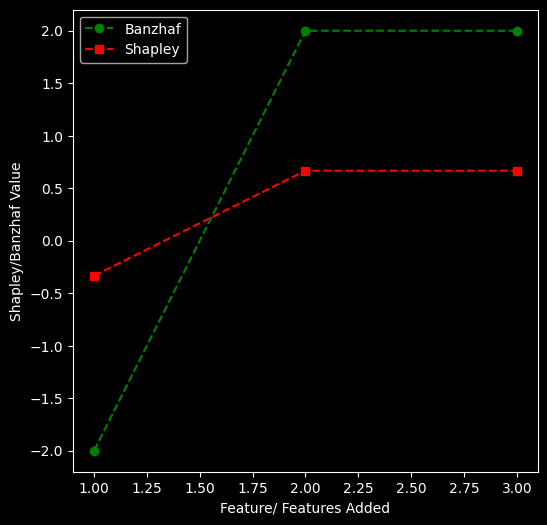

In [59]:
from powerxai.shapley_value import shapley_value

def comparison_between_values_similarity_set_inverse_voting_game():

  xaxis =[]

  yaxis_banzhaf =[]
  yaxis_shapley =[]

  for i in range (1, 4):
    xaxis. append( i )

  for i in range (0, 3):
    yaxis_banzhaf. append( banzhaf_value(i, [0,1,2], similarity_set_inverse_voting_game) )

  for i in range (0, 3):
    yaxis_shapley. append( shapley_value(i, [0,1,2], similarity_set_inverse_voting_game) )

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth(6)
  fig.set_figheight(6)

  plt.xlabel ("Feature/ Features Added")
  plt.ylabel ("Shapley/Banzhaf Value")
  plt.plot(xaxis, yaxis_banzhaf, 'go', linestyle = 'dashed', label= 'Banzhaf')
  plt.plot(xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_similarity_set_inverse_voting_game()

As in the previous case, both of the indices show the same (graph-) behavior, with Shapley's modulus value being tamer. 

3. Sufficiency based Voting Game.

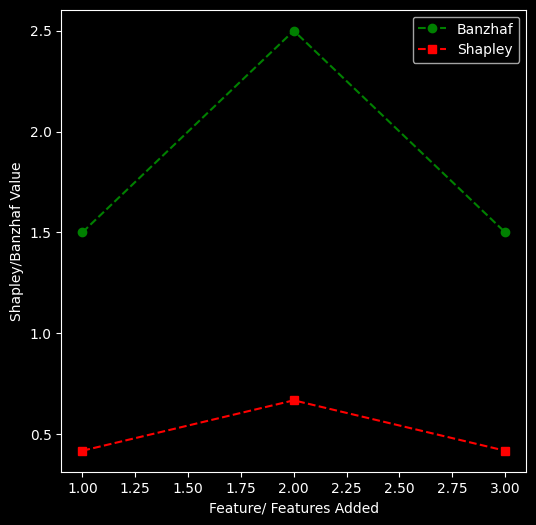

In [65]:
from powerxai.shapley_value import shapley_value

def comparison_between_values_sufficiency_voting_game( ):

  xaxis =[]

  yaxis_banzhaf =[]
  yaxis_shapley =[]

  for i in range (1, 4):
    xaxis. append( i )

  for i in range (0, 3):
    yaxis_banzhaf. append( banzhaf_value(i, [0,1,2], sufficiency_voting_game) )

  for i in range (0, 3):
    yaxis_shapley. append( shapley_value(i, [0,1,2], sufficiency_voting_game) )

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth(6)
  fig.set_figheight(6)

  plt.xlabel ("Feature/ Features Added")
  plt.ylabel ("Shapley/Banzhaf Value")
  plt.plot(xaxis, yaxis_banzhaf, 'go', linestyle = 'dashed', label= 'Banzhaf')
  plt.plot(xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_sufficiency_voting_game( )

Same behavior noticed, as in the previous cases. 